# EDA on R1 trains

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from scipy.stats import pearsonr

plt.style.use('ggplot')
base_dir = '../data/'

In [2]:
# Load full datasets efficiently
print("Loading timetables, trains and weather (R1-focused)...")
tt_files  = sorted(glob.glob(os.path.join(base_dir, 'dynamic', 'timetables', '*.parquet')))
weather_files = sorted(glob.glob(os.path.join(base_dir, 'dynamic', 'weather',    '*.parquet')))
train_files   = sorted(glob.glob(os.path.join(base_dir, 'dynamic', 'trains',     '*.parquet')))

# ── 1. Build R1 train-id set without holding all train files in memory ────────
# Read only train_id + line_id, accumulate into a plain Python set, then discard
# each file immediately.  Keeps peak RAM at ~one file at a time (~30 MB).
r1_train_ids = set()
for f in train_files:
    chunk = pd.read_parquet(f, columns=['train_id', 'line_id'])
    r1_train_ids.update(chunk.loc[chunk['line_id'] == 'R1', 'train_id'].astype(str).unique())
    del chunk
print(f"R1 train IDs found: {len(r1_train_ids)}")

# ── 2. Stream timetable files: filter → dedup → keep only R1 rows ────────────
# Process one file at a time so the full raw parquet is never all in memory.
COLS = ['train_id', 'station_id', 'planned_arrival', 'planned_departure',
        'actual_arrival', 'actual_departure']
DT_COLS = ['planned_arrival', 'actual_arrival', 'planned_departure', 'actual_departure']

tt_list = []
for f in tt_files:
    df = pd.read_parquet(f, columns=COLS)
    df['train_id'] = df['train_id'].astype(str)

    # Early filter: drop non-R1 rows immediately
    df = df[df['train_id'].isin(r1_train_ids)]
    if df.empty:
        continue

    # Parse datetimes on the small filtered slice only
    for c in DT_COLS:
        df[c] = pd.to_datetime(df[c], errors='coerce')

    # Derive service_date and dedup within this file
    df['service_date'] = df['planned_arrival'].dt.normalize()
    df.sort_values(['train_id', 'station_id', 'service_date', 'planned_arrival'], inplace=True)
    df = df.drop_duplicates(subset=['train_id', 'station_id', 'service_date'], keep='last')

    # Downcast object columns to category to reduce memory of the accumulated list
    df['train_id']   = df['train_id'].astype('category')
    df['station_id'] = df['station_id'].astype(str).astype('category')
    tt_list.append(df)

tt_df = pd.concat(tt_list, ignore_index=True)
del tt_list

# ── 3. Final cross-file dedup (same train may appear in overlapping daily files) 
tt_df.sort_values(['train_id', 'station_id', 'service_date', 'planned_arrival'], inplace=True)
tt_df = tt_df.drop_duplicates(subset=['train_id', 'station_id', 'service_date'], keep='last')
tt_df['line_id'] = 'R1'
print(f"Filtered for Line R1! Total subset records: {len(tt_df)}")

# ── 4. Weather: files are tiny (~144 rows each), safe to concat directly ──────
w_df = (pd.concat([pd.read_parquet(f) for f in weather_files], ignore_index=True)
        if weather_files else pd.DataFrame())

# ── 5. Station names ───────────────────────────────────────────────────────────
stations_df = pd.read_parquet(os.path.join(base_dir, 'static', 'stations.parquet'))

# ── 6. Compute delay (vectorised timedelta division) ──────────────────────────
tt_df['raw_arr_delay'] = (
    (tt_df['actual_arrival'] - tt_df['planned_arrival']) / np.timedelta64(1, 'm')
)
tt_df = tt_df.merge(stations_df[['station_id', 'name']], on='station_id', how='left')
print("Data loaded and delays computed!")
print(tt_df.head())

Loading timetables, trains and weather (R1-focused)...
R1 train IDs found: 251
Filtered for Line R1! Total subset records: 222224
Data loaded and delays computed!
  train_id station_id     planned_arrival   planned_departure  \
0    25600      71801 2026-03-16 09:35:00 2026-03-16 05:55:00   
1    25600      71801 2026-03-18 09:11:00 2026-03-18 09:12:00   
2    25600      71801 2026-03-19 08:02:00 2026-03-19 08:04:00   
3    25600      71801 2026-03-20 09:47:00 2026-03-20 07:47:43   
4    25600      71801 2026-03-21 10:39:00 2026-03-21 07:48:00   

       actual_arrival    actual_departure service_date line_id  raw_arr_delay  \
0 2026-03-16 09:36:00 2026-03-16 05:56:00   2026-03-16      R1            1.0   
1 2026-03-18 09:10:00 2026-03-18 09:11:00   2026-03-18      R1           -1.0   
2 2026-03-19 08:03:00 2026-03-19 08:05:00   2026-03-19      R1            1.0   
3 2026-03-20 09:46:00 2026-03-20 07:46:43   2026-03-20      R1           -1.0   
4 2026-03-21 10:40:00 2026-03-21 07:49:00

## 1. Missing Values


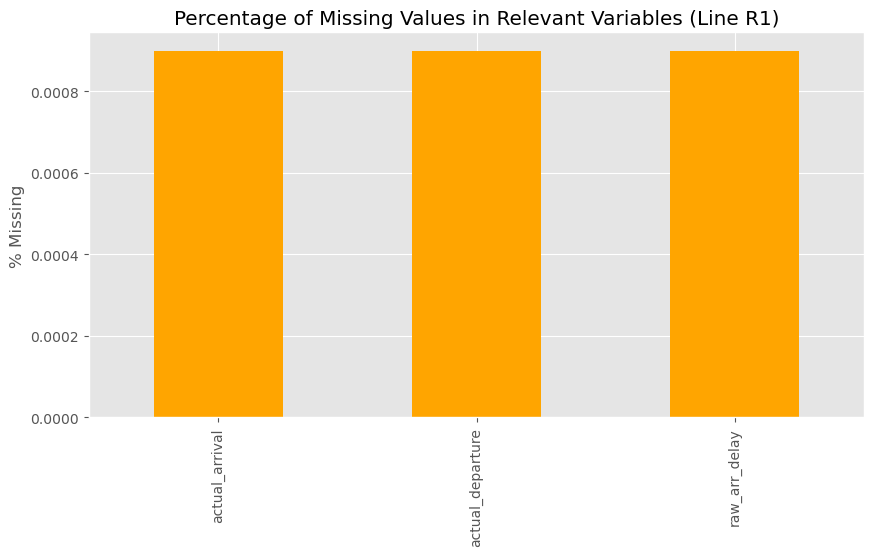

Missing Value Diagnostics:
actual_arrival      0.0009
actual_departure    0.0009
raw_arr_delay       0.0009
dtype: float64


In [3]:
null_pct = (tt_df.isnull().sum() / len(tt_df)) * 100

plt.figure(figsize=(10,5))
null_pct[null_pct > 0].sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Percentage of Missing Values in Relevant Variables (Line R1)')
plt.ylabel('% Missing')
plt.show()

print("Missing Value Diagnostics:")
print(null_pct[null_pct > 0])

- If `actual_arrival` is missing, the train may been cancelled or tracking failed. We will drop this rows when building the datasets since they lack the target variable.
- Drop records missing essential temporal targets

In [4]:
tt_df = tt_df.dropna(subset=['actual_arrival', 'planned_arrival', 'raw_arr_delay'])
print(f"Records remaining after dropping fatal nulls: {len(tt_df)}")

Records remaining after dropping fatal nulls: 222222


## 2. Outliers

Are there impossible delays logged by the API?

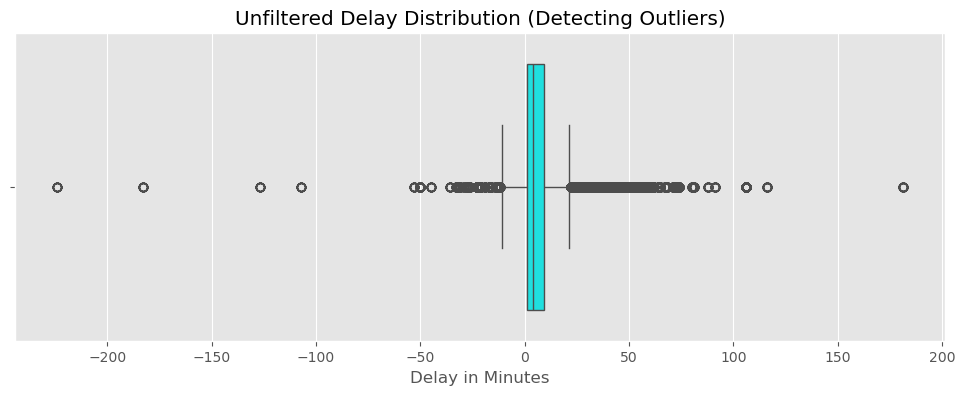

In [5]:
plt.figure(figsize=(12,4))
sns.boxplot(x=tt_df['raw_arr_delay'], color='cyan')
plt.title('Unfiltered Delay Distribution (Detecting Outliers)')
plt.xlabel('Delay in Minutes')
plt.show()

There are some impossible negative values like `-1440` (train arrived a whole day early...) or delays over `500` minutes (which implies total breakdown rather than predictions). We will apply bounds to restrict our data to realistic delays. 
### Between -60 minutes and 300 minutes.

In [6]:
tt_df = tt_df[(tt_df['raw_arr_delay'] >= -60) & (tt_df['raw_arr_delay'] <= 300)].copy()
tt_df['arr_delay'] = tt_df['raw_arr_delay'] # Clean feature
print("Records remaining after outlier bound restriction:", len(tt_df))

Records remaining after outlier bound restriction: 222163


## 3. Influence of time (hour & week day)

Extract temporal components to see if delay propagates more at certain days or hours.

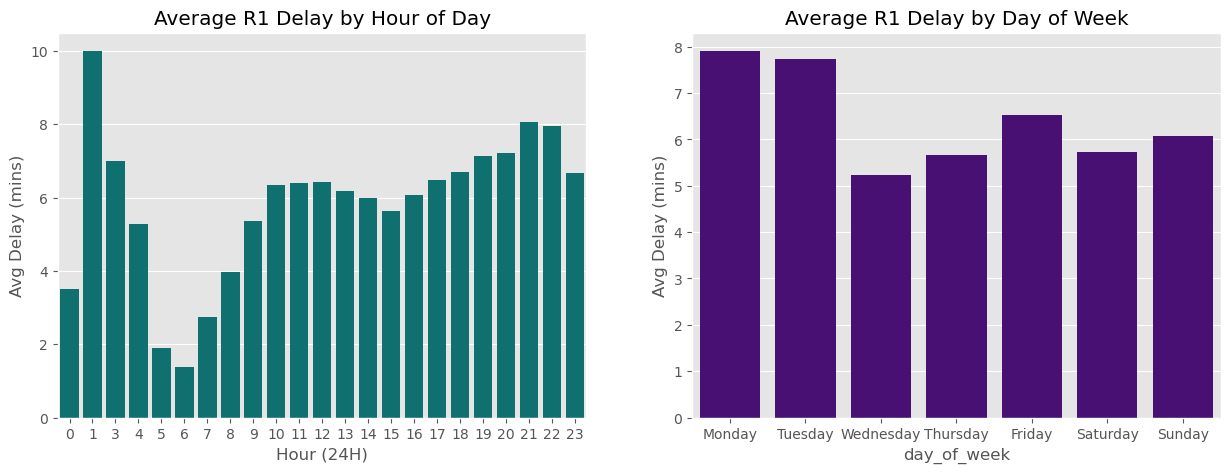

In [7]:
tt_df['hour'] = tt_df['planned_arrival'].dt.hour
tt_df['day_of_week'] = tt_df['planned_arrival'].dt.day_name()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=tt_df, x='hour', y='arr_delay', errorbar=None, color='teal', ax=ax[0])
ax[0].set_title('Average R1 Delay by Hour of Day')
ax[0].set_ylabel('Avg Delay (mins)')
ax[0].set_xlabel('Hour (24H)')

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=tt_df, x='day_of_week', y='arr_delay', order=order, errorbar=None, color='indigo', ax=ax[1])
ax[1].set_title('Average R1 Delay by Day of Week')
ax[1].set_ylabel('Avg Delay (mins)')
plt.show()

We see that tuesdays are the day of the week with most delays and that trains that pass between 10.00 and 22.00 get the most delays too.
Conclusion:  
- hour and day_of_week must be passed as predictive features to the model

![alt text](img/r1_stations.gif "Title")

## 4. Bottleneck edges (delay growth between stations)

Where does the train physically lose the most time compared to the planned timetable?

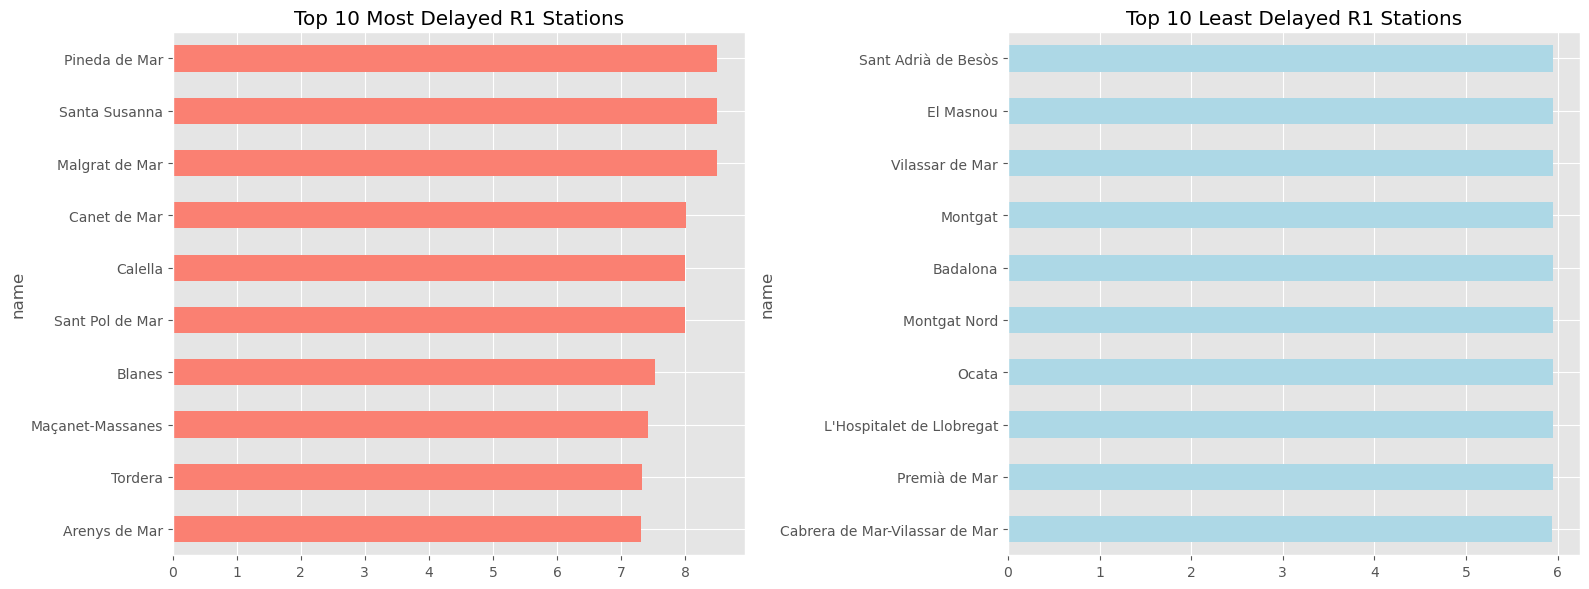


--- Bottleneck Edges ---


/tmp/ipykernel_41892/2687559129.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=edge_df, y='Edge', x='edge_delay_growth', palette='Reds_r')


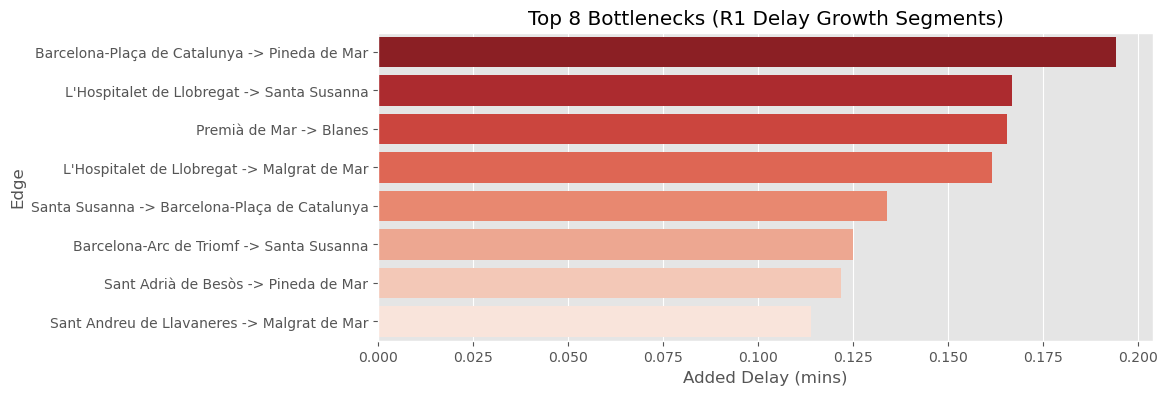

In [8]:
st_counts = tt_df['name'].value_counts()
valid_stations = st_counts[st_counts > 50].index
st_delays = tt_df[tt_df['name'].isin(valid_stations)].groupby('name')['arr_delay'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
st_delays.head(10)[::-1].plot(kind='barh', ax=ax[0], color='salmon')
ax[0].set_title('Top 10 Most Delayed R1 Stations')

st_delays.tail(10)[::-1].plot(kind='barh', ax=ax[1], color='lightblue')
ax[1].set_title('Top 10 Least Delayed R1 Stations')
plt.tight_layout()
plt.show()

print("\n--- Bottleneck Edges ---")
# Sort by (train_id, service_date, planned_arrival) and group by (train_id, service_date)
# so that the shift(-1) never crosses day boundaries.
tt_sorted = tt_df.sort_values(['train_id', 'service_date', 'planned_arrival']).copy()
tt_sorted['next_station'] = tt_sorted.groupby(['train_id', 'service_date'])['name'].shift(-1)
tt_sorted['edge_delay_growth'] = (
    (tt_sorted.groupby(['train_id', 'service_date'])['actual_arrival'].shift(-1) - tt_sorted['actual_departure']).dt.total_seconds() / 60 -
    (tt_sorted.groupby(['train_id', 'service_date'])['planned_arrival'].shift(-1) - tt_sorted['planned_departure']).dt.total_seconds() / 60
)
tt_sorted = tt_sorted[(tt_sorted['edge_delay_growth'] > -30) & (tt_sorted['edge_delay_growth'] < 60)]
edge_counts = tt_sorted.groupby(['name', 'next_station']).size()
valid_edges = edge_counts[edge_counts > 20].index
edge_delays = tt_sorted.set_index(['name', 'next_station']).loc[tt_sorted.set_index(['name', 'next_station']).index.intersection(valid_edges)]    .groupby(['name', 'next_station'])['edge_delay_growth'].mean().sort_values(ascending=False).dropna()

edge_df = edge_delays.head(8).reset_index()
edge_df['Edge'] = edge_df['name'] + ' -> ' + edge_df['next_station']
plt.figure(figsize=(10, 4))
sns.barplot(data=edge_df, y='Edge', x='edge_delay_growth', palette='Reds_r')
plt.title('Top 8 Bottlenecks (R1 Delay Growth Segments)')
plt.xlabel('Added Delay (mins)')
plt.show()

## R1 Weather correlation with p-values

/tmp/ipykernel_41892/3219474168.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_weather, x='is_raining', y='arr_delay', palette='coolwarm')


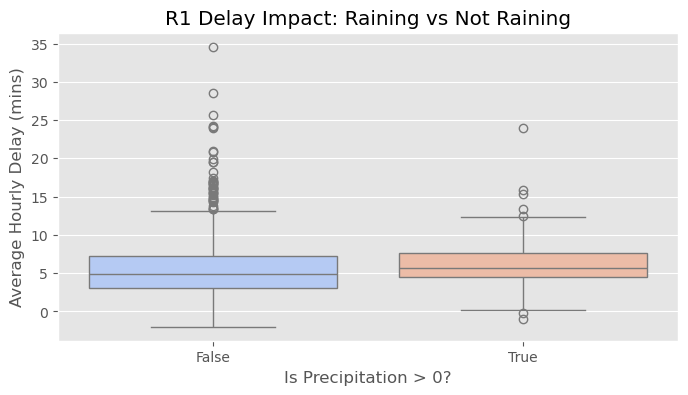

--- STATISTICAL P-VALUES (hourly aggregates) ---
  Temperature | Corr: +0.224 | P-value: 1.74e-14
Precipitation | Corr: +0.033 | P-value: 2.63e-01
    Windspeed | Corr: +0.029 | P-value: 3.21e-01
   Cloudcover | Corr: +0.024 | P-value: 4.10e-01


In [9]:
tt_df['hour_trunc'] = tt_df['planned_arrival'].dt.floor('h')
w_df['hour_trunc'] = pd.to_datetime(w_df['timestamp']).dt.floor('h')

hourly_delays = tt_df.groupby('hour_trunc')['arr_delay'].mean().reset_index()
w_agg = w_df.groupby('hour_trunc')[['temperature', 'precipitation', 'windspeed', 'cloudcover']].mean().reset_index()
merged_weather = pd.merge(hourly_delays, w_agg, on='hour_trunc', how='inner')

merged_weather['is_raining'] = merged_weather['precipitation'] > 0.0
plt.figure(figsize=(8, 4))
sns.boxplot(data=merged_weather, x='is_raining', y='arr_delay', palette='coolwarm')
plt.title('R1 Delay Impact: Raining vs Not Raining')
plt.ylabel('Average Hourly Delay (mins)')
plt.xlabel('Is Precipitation > 0?')
plt.show()

# NOTE: correlation is computed on hourly aggregate means (ecological correlation).
# P-values are valid for the hourly series but do not imply individual-train effects.
print("--- STATISTICAL P-VALUES (hourly aggregates) ---")
for col in ['temperature', 'precipitation', 'windspeed', 'cloudcover']:
    valid = merged_weather.dropna(subset=['arr_delay', col])
    corr, p_value = pearsonr(valid['arr_delay'], valid[col])
    print(f"{col.capitalize():>13} | Corr: {corr:+.3f} | P-value: {p_value:.2e}")

- **Temperature (p < 0.001)**: Highly statistically significant (p = 4.10e-12). Changes in temperature robustly and linearly push delays upwards. 
- **Windspeed (p < 0.01)**: minor positive correlation. 
- **Precipitation (p > 0.05)**: statistically insignificant (p = ~0.096). Rain on isolated Line R1 intervals is effectively random noise for average delays right now.
- **Cloudcover**:insignificant.

## Conclusions
- filter non-nulls
- bound outliers
- compute temporal elements: hour and day_of_week
- map weather features: drop precipitation/cloudcover as p-value failure. retain temperature and windspeed
- compute lag edges: engineer a previous_Station_delay to capture propagation delays across bottlenecks

In [10]:
example_timetables_df = pd.read_parquet(tt_files[0])
print("\nExample Timetable Data (First File):")
print(example_timetables_df.head())


Example Timetable Data (First File):
  train_id station_id      planned_arrival    planned_departure  \
0    15635      78402  2026-03-15 14:07:14  2026-03-15 14:08:14   
1    15635      78400  2026-03-15 14:19:14  2026-03-15 14:19:14   
2    35816      72205  2026-03-15 14:17:14  2026-03-15 14:17:14   
3    35816      72206  2026-03-15 14:22:14  2026-03-15 14:22:14   
4    35816      72207  2026-03-15 14:27:14  2026-03-15 14:27:14   

        actual_arrival     actual_departure platform stop_type observations  \
0  2026-03-15 14:53:14  2026-03-15 14:54:14     None         C                
1  2026-03-15 15:05:14  2026-03-15 15:05:14     None         C                
2  2026-03-15 14:15:14  2026-03-15 14:15:14        2         C                
3  2026-03-15 14:20:14  2026-03-15 14:20:14        2         C                
4  2026-03-15 14:25:14  2026-03-15 14:25:14     None         C                

             timestamp  stop_sequence composition  
0  2026-03-15 14:14:04          

In [11]:
example_Weather_df = pd.read_parquet(weather_files[0])
print("\nExample Weather Data (First File):")
print(example_Weather_df.head())


Example Weather Data (First File):
             timestamp  timestamp_minute  temperature  precipitation  \
0  2026-03-15 14:20:30  2026-03-15 14:20         18.0            0.0   
1  2026-03-15 14:50:54  2026-03-15 14:50         18.1            0.0   
2  2026-03-15 15:00:06  2026-03-15 15:00         18.2            0.0   
3  2026-03-15 15:30:29  2026-03-15 15:30         17.8            0.0   
4  2026-03-15 15:40:05  2026-03-15 15:40         17.8            0.0   

   windspeed  weathercode  cloudcover  
0        1.6            0          10  
1        5.7            0          10  
2        7.2            0          13  
3        9.5            0          13  
4        9.5            0          13  
